# Trapezoidal Rule for Numerical Integration

The Trapezoidal Rule is a numerical method for approximating the definite integral of a function. It works by dividing the area under the curve into a series of trapezoids and summing their areas. This method is an improvement over using rectangles (like in the Riemann sum) because it generally provides a more accurate approximation for a given number of subintervals.

**Steps to apply the Trapezoidal Rule:**

1.  **Define the function and interval:**
    *   Identify the function `f(x)` you want to integrate.
    *   Determine the interval of integration `[a, b]`. `a` is the lower limit and `b` is the upper limit.

2.  **Choose the number of subintervals (n):**
    *   Decide how many trapezoids (`n`) you want to use to approximate the area. A larger `n` generally leads to a more accurate approximation but requires more computation.

3.  **Calculate the width of each subinterval (h):**
    *   The width of each trapezoid (or subinterval) is given by:
        `h = (b - a) / n`

4.  **Determine the x-coordinates of the subintervals:**
    *   These are $x_0, x_1, x_2, ..., x_n$ where:
        *   $x_0 = a$
        *   $x_1 = a + h$
        *   $x_2 = a + 2h$
        *   $\vdots$
        *   $x_n = a + nh = b$

5.  **Evaluate the function at each x-coordinate:**
    *   Calculate $f(x_0), f(x_1), f(x_2), ..., f(x_n)$.

6.  **Apply the Trapezoidal Rule formula:**
    *   The formula for the approximate integral is:
        <br/>Integral $\approx (h / 2) * [f(x_0) + 2f(x_1) + 2f(x_2) + ... + 2f(x_{n-1}) + f(x_n)]$
    *   Notice that the first and last function values are multiplied by 1, while all intermediate function values are multiplied by 2.

**In simpler terms:** You are averaging the height of the two sides of each trapezoid and multiplying by its width ($h$). Then you sum these areas. The formula above is a more efficient way of doing this summation.

In [1]:
import numpy as np

def trapezoidal_method(f, a, b, n):
    """
    Approximates the definite integral of a function f from a to b
    using the trapezoidal method with n subintervals.

    Args:
        f (function): The function to integrate.
        a (float): The lower limit of integration.
        b (float): The upper limit of integration.
        n (int): The number of subintervals.

    Returns:
        float: The approximate value of the definite integral.
    """
    if n <= 0:
        raise ValueError("Number of subintervals (n) must be positive.")
    if b < a:
        raise ValueError("Upper limit (b) must be greater than or equal to lower limit (a).")

    h = (b - a) / n  # Width of each subinterval

    # Calculate x-coordinates of the subintervals
    x = np.linspace(a, b, n + 1)

    # Evaluate the function at each x-coordinate
    y = f(x)

    # Apply the trapezoidal rule formula
    # Sum of first and last terms, plus twice the sum of intermediate terms
    integral = (h / 2) * (y[0] + 2 * np.sum(y[1:n]) + y[n])

    return integral

# --- Example Usage ---

# Define a function to integrate: f(x) = x^2
def my_function(x):
    return x**2

# Define the integration interval and number of subintervals
a_val = 0.0  # Lower limit
b_val = 1.0  # Upper limit
n_val = 10   # Number of subintervals

# Calculate the approximate integral
approx_integral = trapezoidal_method(my_function, a_val, b_val, n_val)

print(f"Integrating f(x) = x^2 from {a_val} to {b_val} with {n_val} subintervals.")
print(f"Approximate integral: {approx_integral}")

# For comparison, the exact integral of x^2 from 0 to 1 is [x^3/3] from 0 to 1 = 1/3 ≈ 0.3333...
exact_integral = 1/3
print(f"Exact integral: {exact_integral}")
print(f"Error: {abs(exact_integral - approx_integral)}")

# Another example: f(x) = sin(x) from 0 to pi
def sin_function(x):
    return np.sin(x)

a_sin = 0.0
b_sin = np.pi
n_sin = 100 # More subintervals for better accuracy

approx_integral_sin = trapezoidal_method(sin_function, a_sin, b_sin, n_sin)

print(f"\nIntegrating f(x) = sin(x) from {a_sin} to {b_sin} with {n_sin} subintervals.")
print(f"Approximate integral: {approx_integral_sin}")

# Exact integral of sin(x) from 0 to pi is [-cos(x)] from 0 to pi = -cos(pi) - (-cos(0)) = -(-1) - (-1) = 1 + 1 = 2
exact_integral_sin = 2.0
print(f"Exact integral: {exact_integral_sin}")
print(f"Error: {abs(exact_integral_sin - approx_integral_sin)}")

Integrating f(x) = x^2 from 0.0 to 1.0 with 10 subintervals.
Approximate integral: 0.3350000000000001
Exact integral: 0.3333333333333333
Error: 0.0016666666666667607

Integrating f(x) = sin(x) from 0.0 to 3.141592653589793 with 100 subintervals.
Approximate integral: 1.9998355038874436
Exact integral: 2.0
Error: 0.0001644961125564226


## Derivation of the Trapezoidal Rule

Let's consider a single subinterval $[x_i, x_{i+1}]$ of width $h = x_{i+1} - x_i$. We want to approximate the area under the curve $f(x)$ over this subinterval using a trapezoid.

The vertices of the trapezoid are $(x_i, 0)$, $(x_{i+1}, 0)$, $(x_{i+1}, f(x_{i+1}))$, and $(x_i, f(x_i))$.

The area of a trapezoid is given by the formula:

Area = (1/2) * (sum of parallel sides) * (height)

In our case, the parallel sides are the function values $f(x_i)$ and $f(x_{i+1})$, and the height is the width of the subinterval $h$.

So, the area of the trapezoid for a single subinterval is:

$$A_i = (1/2) * (f(x_i) + f(x_{i+1})) * h$$

To approximate the total integral over the interval $[a, b]$, we sum the areas of all these trapezoids:

$$\text{Integral} \approx \sum_{i=0}^{n-1} A_i = \sum_{i=0}^{n-1} (1/2) * (f(x_i) + f(x_{i+1})) * h$$

We can factor out $h/2$:

$$\text{Integral}\approx (h/2) * \sum_{i=0}^{n-1} (f(x_i) + f(x_{i+1}))$$

Expanding the sum:

$$\text{Integral}\approx (h/2) * [ (f(x_0) + f(x_1)) + (f(x_1) + f(x_2)) + (f(x_2) + f(x_3)) + ... + (f(x_{n-1}) + f(x_n)) ]$$

Notice that all intermediate terms appear twice (e.g., $f(x_1)$ appears in the first and second terms, $f(x_2)$ in the second and third, and so on). The first term $f(x_0)$ and the last term $f(x_n)$ appear only once.

So, we can rewrite the sum as:

$$\text{Integral}\approx (h/2) * [ f(x_0) + 2f(x_1) + 2f(x_2) + ... + 2f(x_{n-1}) + f(x_n) ]$$

This is the general formula for the Trapezoidal Rule.
***

### Z-Score and Z-Table Values

A **Z-score** (also known as a standard score) measures how many standard deviations an element is from the mean. It's a way to standardize different normal distributions so they can be compared. The formula for a Z-score is:

$$Z = \frac{X - \mu}{\sigma}$$

Where:
*   $X$ is the raw score or data point.
*   $\mu$ (mu) is the mean of the population.
*   $\sigma$ (sigma) is the standard deviation of the population.

A **Z-table** (or standard normal table) provides the cumulative probability associated with a given Z-score. Specifically, it gives the probability that a standard normal random variable (one with mean 0 and standard deviation 1) is less than or equal to a particular Z-score, i.e., $P(Z \le z)$.

The cumulative probability for a Z-score cannot be expressed as a simple algebraic formula. It's defined by the Cumulative Distribution Function (CDF) of the standard normal distribution, which is an integral:

$$\Phi(z) = P(Z \le z) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{z} e^{-t^2/2} dt$$

This integral does not have a closed-form solution in terms of elementary functions and is typically calculated using numerical methods. The values in a Z-table are pre-computed approximations of this integral for various Z-scores.

In [2]:
import numpy as np
from scipy.optimize import brentq
import pandas as pd

# Standard Normal Probability Density Function (PDF)
def standard_normal_pdf(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)

# Wrapper function to calculate CDF using the trapezoidal method
def std_normal_cdf_trapezoidal(z, lower_bound=-8.0, n_intervals=5000):
    """
    Calculates the cumulative distribution function (CDF) for the standard normal
    distribution up to a given z-score using the trapezoidal method.
    """
    # If z is less than lower_bound, the area is practically 0
    if z <= lower_bound:
        return 0.0
    return trapezoidal_method(standard_normal_pdf, lower_bound, z, n_intervals)

# Define the target cumulative probabilities for the confidence intervals
# For a two-tailed CI of C%, we need the Z-score such that P(Z <= z) = 0.5 + (C / 2)
confidence_levels = {
    "80%": 0.5 + (0.80 / 2),  # 0.90
    "85%": 0.5 + (0.85 / 2),  # 0.925
    "88%": 0.5 + (0.88 / 2),  # 0.94
    "90%": 0.5 + (0.90 / 2),  # 0.95
    "95%": 0.5 + (0.95 / 2),  # 0.975
    "98%": 0.5 + (0.98 / 2)   # 0.99
}

# Find the Z-scores for each cumulative probability
z_values = {}
for ci_label, target_prob in confidence_levels.items():
    # Define a function whose root we want to find
    # f(z) = std_normal_cdf_trapezoidal(z) - target_prob = 0
    func_to_solve = lambda z: std_normal_cdf_trapezoidal(z) - target_prob

    # Use brentq to find the root (the z-score)
    # We need a bracket [a, b] where f(a) and f(b) have opposite signs
    # The standard normal distribution is symmetric around 0.
    # For target_prob > 0.5, z will be positive.
    # For standard normal, CDF(-8) is ~0 and CDF(8) is ~1.
    # So, a reasonable search interval is [-8, 8].
    try:
        z_score = brentq(func_to_solve, -8.0, 8.0)
        z_values[ci_label] = z_score
    except ValueError as e:
        z_values[ci_label] = f"Error: {e}"

# Display the results
results_df = pd.DataFrame(list(z_values.items()), columns=['Confidence Interval', 'Z-score'])
print("Z-values for specified confidence intervals (calculated using Trapezoidal Rule for CDF):")
display(results_df)

Z-values for specified confidence intervals (calculated using Trapezoidal Rule for CDF):


,Confidence Interval,Z-score
0,80%,1.281552
1,85%,1.439532
2,88%,1.554774
3,90%,1.644854
4,95%,1.959965
5,98%,2.326349


### Understanding `0.5 + (CI / 2)` for Confidence Intervals

<center>

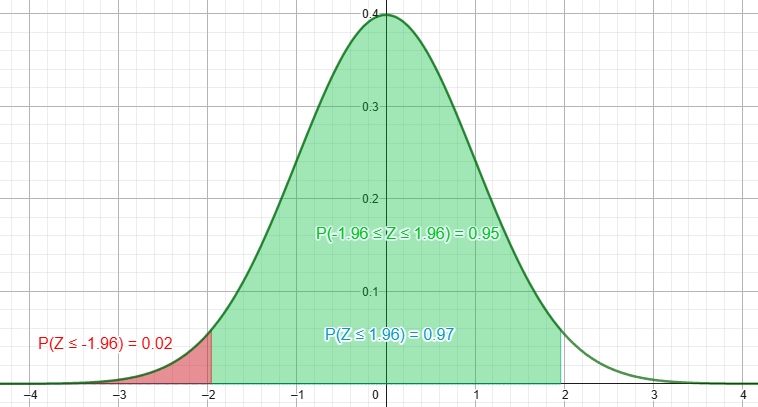
</center>

When we talk about a **Confidence Interval (CI)**, such as an 80%, 90%, or 95% CI, we are typically referring to a **two-tailed interval**. This means the uncertainty (the area outside the interval) is split equally into the two tails of the distribution.

The way we calculate the Z-value for a particular confidence interval $CI$ is by calculating $z$ such that:
$$
CI = P(-z\leq Z\leq z) = P(Z\leq z) - P(Z\leq -z)
$$

Let's break down the logic:

1.  **Total Area Under the Curve is 1:** For any probability distribution, the total area under its curve is 1 (or 100%).

2.  **Central Area:** A confidence level (CI) represents the central area under the standard normal curve that we are *confident* contains the true population parameter. For example, for a 90% CI, the central 90% of the area is of interest.

3.  **Area in the Tails:** If the central area is CI, then the remaining area is $1 - CI$. This remaining area is equally distributed in the two tails of the distribution.
    *   Area in each tail = $(1 - CI) / 2$

4.  **Cumulative Probability (CDF):** A Z-table (or the standard normal CDF) gives the probability $P(Z \le z)$, which is the area under the curve from negative infinity up to a given Z-score $z$.

5.  **Finding the Positive Critical Z-score:** To find the positive Z-score that defines the upper boundary of the confidence interval, we need to consider the cumulative area from the far left up to that Z-score. This cumulative area includes:
    *   The entire left tail.
    *   The entire central area.

    Alternatively, and more simply, it's the area up to the mean (0.5) plus half of the central confidence area:

    *   Area from $-\infty$ to the mean (Z=0) is **0.5**.
    *   Half of the confidence interval (the area from the mean to the positive critical Z-score) is **$CI / 2$**.

    Therefore, the target cumulative probability for the positive critical Z-score is:
    
    **Target Cumulative Probability = $0.5 + (CI / 2)$**

**Example: 90% Confidence Interval**

*   $CI = 0.90$
*   Area in each tail = $(1 - 0.90) / 2 = 0.10 / 2 = 0.05$
*   Target Cumulative Probability = $0.5 + (0.90 / 2) = 0.5 + 0.45 = 0.95$

So, for a 90% CI, we look for the Z-score where the cumulative probability is 0.95. This Z-score will have 5% of the area to its right (the upper tail) and 95% of the area to its left. Due to symmetry, the negative Z-score will have 5% of the area to its left (the lower tail).
***